# Evidence-Grounded Multimodal KG Construction for Multi-Lecture Reasoning

Colab Pro A100 notebook for a publication-oriented pipeline. The goal is a grounded graph where every concept and edge has lecture evidence.

Pipeline: video download, frame/audio preprocessing, Faster-Whisper transcription, high-recall anchor selection, OCR, grounded VLM extraction, canonicalization, KG construction, GraphRAG QA, and evaluation scaffolds.

Default models: Faster-Whisper large-v3, Qwen2.5-VL-7B-Instruct, BGE-large embeddings, EasyOCR.


In [1]:
# 0. Install dependencies
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

packages = [
    'yt-dlp>=2025.1.0', 'faster-whisper>=1.1.0', 'opencv-python-headless>=4.9.0',
    'Pillow>=10.0.0', 'numpy>=1.24.0', 'pandas>=2.0.0', 'tqdm>=4.66.0',
    'networkx>=3.2', 'matplotlib>=3.8.0', 'scikit-learn>=1.4.0',
    'sentence-transformers>=3.0.0', 'transformers>=4.49.0', 'accelerate>=0.30.0',
    'qwen-vl-utils>=0.0.8', 'easyocr>=1.7.0', 'rapidfuzz>=3.8.0'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
print('Install complete. Restart runtime if Colab requests it, then continue.')


Mounted at /content/drive
Install complete. Restart runtime if Colab requests it, then continue.


In [2]:
# 1. Imports, config, and lecture list
import os, re, cv2, json, math, pickle, warnings, subprocess
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Dict, List, Any, Optional
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from rapidfuzz import fuzz
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
warnings.filterwarnings('ignore')

@dataclass
class PipelineConfig:
    drive_root: str = '/content/drive/MyDrive/MultiLectureKG'
    run_name: str = 'evidence_grounded_run_001'
    frame_rate: float = 1.0
    video_quality: str = 'best[height<=720]'
    asr_model: str = 'large-v3'
    asr_compute_type: str = 'float16'
    target_anchor_percentage: float = 18.0
    min_anchors_per_lecture: int = 80
    max_anchors_per_lecture: int = 260
    min_anchor_distance_sec: int = 4
    transcript_window_before: float = 15.0
    transcript_window_after: float = 22.0
    vlm_model: str = 'Qwen/Qwen2.5-VL-7B-Instruct'
    embedding_model: str = 'BAAI/bge-large-en-v1.5'
    use_4bit_vlm: bool = False
    min_concept_confidence: float = 0.55
    min_relation_confidence: float = 0.55
    dedupe_embedding_threshold: float = 0.94
    evidence_fuzzy_threshold: int = 72
    retrieval_top_k: int = 6
    retrieval_min_score: float = 0.35

CFG = PipelineConfig()
RUN_DIR = Path(CFG.drive_root) / 'runs' / CFG.run_name
DIRS = {
    'raw_videos': RUN_DIR / 'raw' / 'videos',
    'frames': RUN_DIR / 'raw' / 'frames',
    'audio': RUN_DIR / 'raw' / 'audio',
    'transcripts': RUN_DIR / 'processed' / 'transcripts',
    'anchors': RUN_DIR / 'processed' / 'anchors',
    'ocr': RUN_DIR / 'processed' / 'ocr',
    'extractions': RUN_DIR / 'processed' / 'extractions',
    'knowledge': RUN_DIR / 'processed' / 'knowledge',
    'evaluation': RUN_DIR / 'evaluation',
}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

LECTURES = [
    {'video_id': 'neural_net_01', 'url': 'https://www.youtube.com/watch?v=aircAruvnKk', 'title': 'Neural Networks'},
    {'video_id': 'neural_net_02', 'url': 'https://www.youtube.com/watch?v=IHZwWFHWa-w', 'title': 'Gradient Descent'},
    {'video_id': 'neural_net_03', 'url': 'https://www.youtube.com/watch?v=Ilg3gGewQ5U', 'title': 'Backpropagation'},
]

def save_json(path: Path, data: Any):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

def load_json(path: Path) -> Any:
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def clean_text(text: str) -> str:
    return re.sub(r'\s+', ' ', text or '').strip()

def normalize_name(name: str) -> str:
    name = clean_text(name).lower()
    name = re.sub(r'[^a-z0-9+.# /_-]+', '', name)
    name = re.sub(r'\s+', ' ', name).strip(' -_/')
    aliases = {
        'cost function': 'loss function',
        'error function': 'loss function',
        'neural net': 'neural network',
        'artificial neural network': 'neural network',
        'activation': 'activation function',
        'sigmoid function': 'sigmoid',
        'stochastic gradient descent': 'gradient descent',
    }
    return aliases.get(name, name)

def evidence_supported(term: str, evidence: str, threshold: int = CFG.evidence_fuzzy_threshold) -> bool:
    term_n, ev = normalize_name(term), clean_text(evidence).lower()
    if not term_n or not ev:
        return False
    return term_n in ev or fuzz.partial_ratio(term_n, ev) >= threshold

def timestamp_to_frame_id(timestamp: float) -> int:
    return int(round(timestamp * CFG.frame_rate))

save_json(RUN_DIR / 'manifest.json', {'created_at': datetime.now().isoformat(), 'config': asdict(CFG), 'dirs': {k: str(v) for k, v in DIRS.items()}})
save_json(RUN_DIR / 'lectures.json', LECTURES)
print('Run dir:', RUN_DIR)
pd.DataFrame(LECTURES)


Run dir: /content/drive/MyDrive/MultiLectureKG/runs/evidence_grounded_run_001


,video_id,url,title
0,neural_net_01,https://www.youtube.com/watch?v=aircAruvnKk,Neural Networks
1,neural_net_02,https://www.youtube.com/watch?v=IHZwWFHWa-w,Gradient Descent
2,neural_net_03,https://www.youtube.com/watch?v=Ilg3gGewQ5U,Backpropagation


In [3]:
# 2. Download videos, extract audio, and extract frames
import yt_dlp

class VideoDownloader:
    def __init__(self, output_dir: Path):
        self.output_dir = output_dir
    def download(self, lec: Dict) -> Dict:
        video_id = lec['video_id']
        existing = [p for p in self.output_dir.glob(f'{video_id}.*') if p.suffix.lower() in ['.mp4', '.webm', '.mkv']]
        if existing:
            print('[skip video]', existing[0])
            return {**lec, 'video_path': str(existing[0])}
        opts = {'format': CFG.video_quality, 'outtmpl': str(self.output_dir / f'{video_id}.%(ext)s'), 'noplaylist': True, 'merge_output_format': 'mp4'}
        with yt_dlp.YoutubeDL(opts) as ydl:
            info = ydl.extract_info(lec['url'], download=True)
        files = [p for p in self.output_dir.glob(f'{video_id}.*') if p.suffix.lower() in ['.mp4', '.webm', '.mkv']]
        if not files:
            raise FileNotFoundError(video_id)
        return {**lec, 'video_path': str(files[0]), 'yt_title': info.get('title'), 'duration': info.get('duration')}

class Preprocessor:
    def extract_audio(self, video_path: str, video_id: str) -> str:
        out = DIRS['audio'] / f'{video_id}.wav'
        if out.exists():
            print('[skip audio]', out)
            return str(out)
        cmd = ['ffmpeg', '-y', '-i', video_path, '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1', str(out)]
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        return str(out)
    def extract_frames(self, video_path: str, video_id: str) -> List[Dict]:
        out_dir = DIRS['frames'] / video_id
        out_dir.mkdir(parents=True, exist_ok=True)
        meta_path = out_dir / 'frame_metadata.json'
        if meta_path.exists():
            print('[skip frames]', meta_path)
            return load_json(meta_path)
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = total / fps
        interval = max(1, int(round(fps / CFG.frame_rate)))
        meta, frame_count, saved = [], 0, 0
        pbar = tqdm(total=int(duration * CFG.frame_rate), desc=f'frames:{video_id}')
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_count % interval == 0:
                ts = frame_count / fps
                filename = f'frame_{saved:06d}.jpg'
                path = out_dir / filename
                cv2.imwrite(str(path), frame, [cv2.IMWRITE_JPEG_QUALITY, 90])
                meta.append({'frame_id': saved, 'timestamp': ts, 'frame_number': frame_count, 'filename': filename, 'path': str(path)})
                saved += 1
                pbar.update(1)
            frame_count += 1
        pbar.close()
        cap.release()
        save_json(meta_path, meta)
        return meta

lecture_records = [VideoDownloader(DIRS['raw_videos']).download(x) for x in LECTURES]
pre = Preprocessor()
for rec in lecture_records:
    rec['audio_path'] = pre.extract_audio(rec['video_path'], rec['video_id'])
    frames = pre.extract_frames(rec['video_path'], rec['video_id'])
    rec['num_frames'] = len(frames)
save_json(RUN_DIR / 'lecture_records.json', lecture_records)
pd.DataFrame(lecture_records)[['video_id', 'num_frames', 'audio_path']]


[youtube] Extracting URL: https://www.youtube.com/watch?v=aircAruvnKk
[youtube] aircAruvnKk: Downloading webpage


[youtube] aircAruvnKk: Downloading android vr player API JSON
[info] aircAruvnKk: Downloading 1 format(s): 18
[download] Destination: /content/drive/MyDrive/MultiLectureKG/runs/evidence_grounded_run_001/raw/videos/neural_net_01.mp4
[download] 100% of   34.84MiB in 00:00:01 at 34.48MiB/s  
[youtube] Extracting URL: https://www.youtube.com/watch?v=IHZwWFHWa-w
[youtube] IHZwWFHWa-w: Downloading webpage


[youtube] IHZwWFHWa-w: Downloading android vr player API JSON
[info] IHZwWFHWa-w: Downloading 1 format(s): 18
[download] Destination: /content/drive/MyDrive/MultiLectureKG/runs/evidence_grounded_run_001/raw/videos/neural_net_02.mp4
[download] 100% of   46.54MiB in 00:00:01 at 33.78MiB/s  
[youtube] Extracting URL: https://www.youtube.com/watch?v=Ilg3gGewQ5U
[youtube] Ilg3gGewQ5U: Downloading webpage


[youtube] Ilg3gGewQ5U: Downloading android vr player API JSON
[info] Ilg3gGewQ5U: Downloading 1 format(s): 18
[download] Destination: /content/drive/MyDrive/MultiLectureKG/runs/evidence_grounded_run_001/raw/videos/neural_net_03.mp4
[download] 100% of   26.26MiB in 00:00:00 at 35.64MiB/s  


frames:neural_net_01:   0%|          | 0/1119 [00:00<?, ?it/s]

frames:neural_net_02:   0%|          | 0/1232 [00:00<?, ?it/s]

frames:neural_net_03:   0%|          | 0/766 [00:00<?, ?it/s]

,video_id,num_frames,audio_path
0,neural_net_01,1120,/content/drive/MyDrive/MultiLectureKG/runs/evi...
1,neural_net_02,1232,/content/drive/MyDrive/MultiLectureKG/runs/evi...
2,neural_net_03,766,/content/drive/MyDrive/MultiLectureKG/runs/evi...


In [4]:
# 3. Transcribe with Faster-Whisper
from faster_whisper import WhisperModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
whisper_model = WhisperModel(CFG.asr_model, device=DEVICE, compute_type=CFG.asr_compute_type if DEVICE == 'cuda' else 'int8')

def transcribe_audio(audio_path: str, video_id: str) -> Dict:
    out = DIRS['transcripts'] / f'{video_id}_transcript.json'
    if out.exists():
        print('[skip transcript]', out)
        return load_json(out)
    segments, info = whisper_model.transcribe(audio_path, language='en', vad_filter=True, word_timestamps=True, beam_size=5)
    result_segments, full = [], []
    for idx, seg in enumerate(tqdm(list(segments), desc=f'transcribe:{video_id}')):
        text = clean_text(seg.text)
        full.append(text)
        result_segments.append({'segment_id': idx, 'start': float(seg.start), 'end': float(seg.end), 'text': text, 'primary_frame_id': timestamp_to_frame_id((seg.start + seg.end) / 2)})
    data = {'video_id': video_id, 'language': info.language, 'duration': info.duration, 'text': clean_text(' '.join(full)), 'segments': result_segments}
    save_json(out, data)
    return data

for rec in lecture_records:
    tx = transcribe_audio(rec['audio_path'], rec['video_id'])
    rec['transcript_path'] = str(DIRS['transcripts'] / f"{rec['video_id']}_transcript.json")
    rec['num_segments'] = len(tx['segments'])
    rec['num_words'] = len(tx['text'].split())
save_json(RUN_DIR / 'lecture_records.json', lecture_records)
pd.DataFrame(lecture_records)[['video_id', 'num_segments', 'num_words']]


transcribe:neural_net_01:   0%|          | 0/287 [00:00<?, ?it/s]

transcribe:neural_net_02:   0%|          | 0/283 [00:00<?, ?it/s]

transcribe:neural_net_03:   0%|          | 0/186 [00:00<?, ?it/s]

,video_id,num_segments,num_words
0,neural_net_01,287,3277
1,neural_net_02,283,3698
2,neural_net_03,186,2222


In [5]:
# 4. High-recall anchor selection
ANCHOR_KEYWORDS = ['define','defined as','definition','means','refers to','called','known as','important','intuition','example','equation','formula','matrix','derivative','gradient','loss','cost','activation','weight','bias','layer','neuron','backpropagation','learning rate','training','optimization','prerequisite','depends on','used for','used to','minimize','computed','chain rule']
RELATION_CUES = ['depends on','requires','uses','used to','part of','component','minimize','optimizes','computed by','example of']

class AnchorSelector:
    def frame_change_scores(self, meta):
        scores = np.zeros(len(meta))
        prev = None
        for i, fm in enumerate(tqdm(meta, desc='visual diff')):
            img = cv2.imread(fm['path'])
            if img is None:
                continue
            gray = cv2.cvtColor(cv2.resize(img, (320, 180)), cv2.COLOR_BGR2GRAY)
            if prev is not None:
                scores[i] = float(np.mean(cv2.absdiff(prev, gray)))
            prev = gray
        if scores.max() > scores.min():
            scores = np.minimum(scores, np.percentile(scores, 99))
            scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
        return scores
    def transcript_scores(self, segments, n):
        scores = np.zeros(n)
        reasons = defaultdict(list)
        for seg in segments:
            text = seg.get('text', '').lower()
            fid = seg.get('primary_frame_id')
            if fid is None or fid < 0 or fid >= n:
                continue
            kws = [kw for kw in ANCHOR_KEYWORDS if kw in text]
            rels = [kw for kw in RELATION_CUES if kw in text]
            score = min(1.0, len(kws) / 3.0) + (0.7 if rels else 0.0) + (0.2 if '?' in seg.get('text', '') else 0.0)
            if kws:
                reasons[fid].append('keyword:' + ','.join(kws[:3]))
            if rels:
                reasons[fid].append('relation_cue:' + ','.join(rels[:2]))
            scores[fid] = max(scores[fid], score)
        if scores.max() > 0:
            scores = scores / scores.max()
        return scores, reasons
    def first_mention_scores(self, segments, n):
        sentences = [s['text'] for s in segments if len(s['text'].split()) >= 4]
        scores = np.zeros(n)
        reasons = defaultdict(list)
        if len(sentences) < 5:
            return scores, reasons
        try:
            vec = TfidfVectorizer(ngram_range=(1,3), stop_words='english', max_features=100).fit(sentences)
            terms = [t for t in vec.get_feature_names_out() if len(t) >= 4 and not t.isdigit()]
        except Exception:
            terms = []
        seen = set()
        for seg in segments:
            low = seg['text'].lower()
            fid = seg.get('primary_frame_id')
            if fid is None or fid < 0 or fid >= n:
                continue
            for term in terms:
                if term not in seen and term in low:
                    scores[fid] = 1.0
                    reasons[fid].append('first_mention:' + term)
                    seen.add(term)
                    break
        return scores, reasons
    def context_window(self, ts, segments):
        a, b = ts - CFG.transcript_window_before, ts + CFG.transcript_window_after
        return clean_text(' '.join(s['text'] for s in segments if s['end'] >= a and s['start'] <= b))
    def select(self, video_id):
        out = DIRS['anchors'] / f'{video_id}_anchors.json'
        if out.exists():
            print('[skip anchors]', out)
            return load_json(out)
        meta = load_json(DIRS['frames'] / video_id / 'frame_metadata.json')
        transcript = load_json(DIRS['transcripts'] / f'{video_id}_transcript.json')
        n = len(meta)
        visual = self.frame_change_scores(meta)
        text, tr = self.transcript_scores(transcript['segments'], n)
        first, fr = self.first_mention_scores(transcript['segments'], n)
        final = 0.30 * visual + 0.45 * text + 0.25 * first
        if final.max() > final.min():
            final = (final - final.min()) / (final.max() - final.min() + 1e-8)
        target = max(CFG.min_anchors_per_lecture, min(CFG.max_anchors_per_lecture, int(n * CFG.target_anchor_percentage / 100)))
        selected = []
        for idx in np.argsort(final)[::-1]:
            idx = int(idx)
            ts = meta[idx]['timestamp']
            if any(abs(ts - a['timestamp']) < CFG.min_anchor_distance_sec for a in selected):
                continue
            reasons = tr.get(idx, []) + fr.get(idx, []) + (['visual_change'] if visual[idx] > 0.35 else [])
            selected.append({'anchor_id': len(selected), 'frame_id': idx, 'timestamp': float(ts), 'frame_path': meta[idx]['path'], 'score': float(final[idx]), 'signals': {'visual': float(visual[idx]), 'text': float(text[idx]), 'first_mention': float(first[idx])}, 'reasons': reasons, 'transcript_window': self.context_window(ts, transcript['segments'])})
            if len(selected) >= target:
                break
        selected = sorted(selected, key=lambda x: x['timestamp'])
        for i, a in enumerate(selected):
            a['anchor_id'] = i
        result = {'video_id': video_id, 'num_frames': n, 'num_anchors': len(selected), 'anchors': selected}
        save_json(out, result)
        return result

selector = AnchorSelector()
rows = []
for rec in lecture_records:
    data = selector.select(rec['video_id'])
    rows.append({'video_id': rec['video_id'], 'num_frames': data['num_frames'], 'num_anchors': data['num_anchors']})
pd.DataFrame(rows)


visual diff:   0%|          | 0/1120 [00:00<?, ?it/s]

visual diff:   0%|          | 0/1232 [00:00<?, ?it/s]

visual diff:   0%|          | 0/766 [00:00<?, ?it/s]

,video_id,num_frames,num_anchors
0,neural_net_01,1120,201
1,neural_net_02,1232,221
2,neural_net_03,766,137


In [6]:
# 5. OCR selected anchors
import easyocr
ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

def run_ocr(video_id):
    out = DIRS['ocr'] / f'{video_id}_ocr.json'
    if out.exists():
        print('[skip OCR]', out)
        return load_json(out)
    anchors = load_json(DIRS['anchors'] / f'{video_id}_anchors.json')['anchors']
    items = []
    for a in tqdm(anchors, desc=f'ocr:{video_id}'):
        try:
            res = ocr_reader.readtext(a['frame_path'], detail=1, paragraph=True)
            texts = []
            for item in res:
                bbox, text = item[0], item[1]
                conf = item[2] if len(item) > 2 and isinstance(item[2], (float, int)) else None
                if clean_text(text):
                    texts.append({'text': clean_text(text), 'confidence': None if conf is None else float(conf)})
            ocr_text = clean_text(' '.join(x['text'] for x in texts))
        except Exception:
            texts, ocr_text = [], ''
        items.append({'anchor_id': a['anchor_id'], 'frame_id': a['frame_id'], 'timestamp': a['timestamp'], 'frame_path': a['frame_path'], 'ocr_text': ocr_text, 'ocr_items': texts})
    data = {'video_id': video_id, 'ocr': items}
    save_json(out, data)
    return data

rows = []
for rec in lecture_records:
    data = run_ocr(rec['video_id'])
    rows.append({'video_id': rec['video_id'], 'anchors': len(data['ocr']), 'ocr_nonempty': sum(1 for x in data['ocr'] if x['ocr_text'])})
pd.DataFrame(rows)


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

ocr:neural_net_01:   0%|          | 0/201 [00:00<?, ?it/s]

ocr:neural_net_02:   0%|          | 0/221 [00:00<?, ?it/s]

ocr:neural_net_03:   0%|          | 0/137 [00:00<?, ?it/s]

,video_id,anchors,ocr_nonempty
0,neural_net_01,201,195
1,neural_net_02,221,203
2,neural_net_03,137,131


In [7]:
# 6. Load VLM and embedding model
from transformers import AutoProcessor
from qwen_vl_utils import process_vision_info
try:
    from transformers import Qwen2_5_VLForConditionalGeneration as VLMClass
except Exception:
    from transformers import AutoModelForVision2Seq as VLMClass

kwargs = {'torch_dtype': torch.bfloat16 if torch.cuda.is_available() else torch.float32, 'device_map': 'auto'}
if CFG.use_4bit_vlm:
    from transformers import BitsAndBytesConfig
    kwargs['quantization_config'] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)

vlm_model = VLMClass.from_pretrained(CFG.vlm_model, **kwargs)
vlm_processor = AutoProcessor.from_pretrained(CFG.vlm_model)
embedder = SentenceTransformer(CFG.embedding_model, device='cuda' if torch.cuda.is_available() else 'cpu')
print('Models loaded')


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/57.6k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Models loaded


In [8]:
# 7. Evidence-grounded extraction with Qwen2.5-VL
RELATION_TYPES = ['prerequisite_of','component_of','uses','optimizes','computed_by','example_of','contrasts_with','related_to']
EXTRACTION_SYSTEM = 'You are an evidence-grounded educational knowledge extraction system. Extract only concepts and relationships explicitly supported by the transcript window, OCR text, or visible image. Return empty arrays when evidence is insufficient. Do not use outside knowledge. Return strict JSON only.'

def candidate_terms_from_text(text, max_terms=30):
    chunks = [s.strip() for s in re.split(r'[.!?;:\n]', text) if len(s.split()) >= 3]
    if len(chunks) < 2:
        return []
    try:
        vec = TfidfVectorizer(ngram_range=(1,3), stop_words='english', max_features=80)
        X = vec.fit_transform(chunks)
        scores = np.asarray(X.mean(axis=0)).ravel()
        terms = vec.get_feature_names_out()
        out = []
        for i in np.argsort(scores)[::-1]:
            t = terms[i].strip().lower()
            if len(t) >= 4 and not t.isdigit() and t not in out:
                out.append(t)
            if len(out) >= max_terms:
                break
        return out
    except Exception:
        return []

def extraction_prompt(video_id, anchor, ocr_text):
    candidates = candidate_terms_from_text(anchor.get('transcript_window','') + ' ' + ocr_text)
    return f'''Lecture: {video_id}
Timestamp seconds: {anchor['timestamp']:.1f}
Anchor reasons: {anchor.get('reasons', [])}

Transcript window:
<transcript>
{anchor.get('transcript_window','')[:3500]}
</transcript>

OCR text from frame:
<ocr>
{ocr_text[:1500]}
</ocr>

Candidate terms to validate, not blindly include:
{candidates[:30]}

Task:
Extract only specific technical concepts and typed relationships with evidence. Allowed relationship types: {RELATION_TYPES}. Every concept and relationship must include evidence_quote, source/source_type, and confidence 0-1. If no useful content exists, return empty arrays.

JSON schema:
{{"concepts":[{{"name":"technical term","definition":"one grounded sentence","evidence_quote":"short quote","source":"transcript|ocr|both|visual","confidence":0.0}}],"relationships":[{{"source":"concept A","target":"concept B","type":"uses","evidence_quote":"short quote","source_type":"transcript|ocr|both|visual","confidence":0.0}}]}}'''

def extract_json_object(text):
    text = re.sub(r'^```json\s*', '', text.strip())
    text = re.sub(r'```$', '', text).strip()
    m = re.search(r'\{.*\}', text, flags=re.DOTALL)
    if not m:
        return {'concepts': [], 'relationships': [], 'parse_error': 'no_json', 'raw': text[:1000]}
    try:
        return json.loads(m.group(0))
    except Exception as e:
        return {'concepts': [], 'relationships': [], 'parse_error': str(e), 'raw': text[:1000]}

def vlm_extract_anchor(video_id, anchor, ocr_text):
    prompt = extraction_prompt(video_id, anchor, ocr_text)
    messages = [
        {'role': 'system', 'content': EXTRACTION_SYSTEM},
        {'role': 'user', 'content': [{'type': 'image', 'image': anchor['frame_path']}, {'type': 'text', 'text': prompt}]}
    ]
    text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = vlm_processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors='pt').to(vlm_model.device)
    with torch.no_grad():
        out = vlm_model.generate(**inputs, max_new_tokens=900, do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out)]
    response = vlm_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    parsed = extract_json_object(response)
    parsed.update({'raw_response': response, 'anchor_id': anchor['anchor_id'], 'frame_id': anchor['frame_id'], 'timestamp': anchor['timestamp'], 'frame_path': anchor['frame_path'], 'transcript_window': anchor.get('transcript_window',''), 'ocr_text': ocr_text, 'video_id': video_id})
    return parsed

def run_extraction(video_id, limit_anchors: Optional[int] = None):
    out = DIRS['extractions'] / f'{video_id}_raw_extractions.json'
    if out.exists() and limit_anchors is None:
        print('[skip extraction]', out)
        return load_json(out)
    anchors = load_json(DIRS['anchors'] / f'{video_id}_anchors.json')['anchors']
    ocr_lookup = {x['anchor_id']: x for x in load_json(DIRS['ocr'] / f'{video_id}_ocr.json')['ocr']}
    if limit_anchors is not None:
        anchors = anchors[:limit_anchors]
    items = []
    for a in tqdm(anchors, desc=f'vlm_extract:{video_id}'):
        ocr_text = ocr_lookup.get(a['anchor_id'], {}).get('ocr_text', '')
        try:
            item = vlm_extract_anchor(video_id, a, ocr_text)
        except Exception as e:
            item = {'video_id': video_id, 'anchor_id': a['anchor_id'], 'frame_id': a['frame_id'], 'timestamp': a['timestamp'], 'frame_path': a['frame_path'], 'concepts': [], 'relationships': [], 'error': str(e), 'transcript_window': a.get('transcript_window',''), 'ocr_text': ocr_text}
        items.append(item)
        if len(items) % 20 == 0:
            save_json(out, {'video_id': video_id, 'items': items, 'partial': True})
    data = {'video_id': video_id, 'items': items, 'partial': False}
    save_json(out, data)
    return data

# Optional smoke test before full extraction:
# run_extraction('neural_net_01', limit_anchors=5)

rows = []
for rec in lecture_records:
    data = run_extraction(rec['video_id'])
    rows.append({'video_id': rec['video_id'], 'anchors': len(data['items']), 'raw_concepts': sum(len(x.get('concepts',[]) or []) for x in data['items']), 'raw_relationships': sum(len(x.get('relationships',[]) or []) for x in data['items'])})
pd.DataFrame(rows)


vlm_extract:neural_net_01:   0%|          | 0/201 [00:00<?, ?it/s]

vlm_extract:neural_net_02:   0%|          | 0/221 [00:00<?, ?it/s]

vlm_extract:neural_net_03:   0%|          | 0/137 [00:00<?, ?it/s]

,video_id,anchors,raw_concepts,raw_relationships
0,neural_net_01,201,409,145
1,neural_net_02,221,445,136
2,neural_net_03,137,301,119


In [9]:
# 8. Validate concepts/relationships and canonicalize entities
BAD_CONCEPTS = {'concept','example','definition','problem','solution','video','frame','image','positive','negative','active','inactive','important','question','answer'}

def validate_concept(c, item, video_id):
    name = normalize_name(c.get('name',''))
    definition = clean_text(c.get('definition',''))
    quote = clean_text(c.get('evidence_quote',''))
    source = c.get('source','transcript')
    try:
        conf = float(c.get('confidence',0.0))
    except Exception:
        conf = 0.0
    pool = clean_text(' '.join([quote, item.get('transcript_window',''), item.get('ocr_text','')]))
    if not name or name in BAD_CONCEPTS or len(name) < 3:
        return None
    if len(definition) < 15 or conf < CFG.min_concept_confidence or not quote:
        return None
    if source != 'visual' and not evidence_supported(name, pool):
        return None
    if source == 'visual' and conf < 0.75:
        return None
    return {'canonical_name': name, 'name': clean_text(c.get('name', name)), 'definition': definition, 'evidence_quote': quote, 'source': source, 'confidence': conf, 'video_id': video_id, 'anchor_id': item['anchor_id'], 'frame_id': item['frame_id'], 'timestamp': item['timestamp'], 'frame_path': item['frame_path']}

def validate_relationship(r, item, video_id):
    src, tgt, typ = normalize_name(r.get('source','')), normalize_name(r.get('target','')), clean_text(r.get('type','related_to'))
    quote = clean_text(r.get('evidence_quote',''))
    try:
        conf = float(r.get('confidence',0.0))
    except Exception:
        conf = 0.0
    if not src or not tgt or src == tgt or typ not in RELATION_TYPES or conf < CFG.min_relation_confidence or not quote:
        return None
    return {'source': src, 'target': tgt, 'type': typ, 'evidence_quote': quote, 'confidence': conf, 'video_id': video_id, 'anchor_id': item['anchor_id'], 'frame_id': item['frame_id'], 'timestamp': item['timestamp']}

concept_mentions, relation_mentions = [], []
for rec in lecture_records:
    video_id = rec['video_id']
    data = load_json(DIRS['extractions'] / f'{video_id}_raw_extractions.json')
    for item in data['items']:
        for c in item.get('concepts', []) or []:
            vc = validate_concept(c, item, video_id)
            if vc:
                concept_mentions.append(vc)
        for r in item.get('relationships', []) or []:
            vr = validate_relationship(r, item, video_id)
            if vr:
                relation_mentions.append(vr)

def build_canonical_concepts(mentions):
    if not mentions:
        return {}, {}
    grouped = defaultdict(list)
    for m in mentions:
        grouped[m['canonical_name']].append(m)
    names = list(grouped.keys())
    emb = embedder.encode(names, normalize_embeddings=True, show_progress_bar=True)
    parent = {n: n for n in names}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra if len(ra) <= len(rb) else rb
    sim = cosine_similarity(emb)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            if sim[i, j] >= CFG.dedupe_embedding_threshold:
                overlap = len(set(names[i].split()) & set(names[j].split())) / max(1, min(len(names[i].split()), len(names[j].split())))
                if overlap >= 0.5 or fuzz.token_sort_ratio(names[i], names[j]) >= 88:
                    union(names[i], names[j])
    alias_to_canon, clusters = {}, defaultdict(list)
    for n in names:
        root = find(n)
        alias_to_canon[n] = root
        clusters[root].extend(grouped[n])
    canonical = {}
    for root, ms in clusters.items():
        defs, seen = [], set()
        for m in sorted(ms, key=lambda x: x['confidence'], reverse=True):
            key = m['definition'].lower()
            if key not in seen:
                defs.append({'definition': m['definition'], 'video_id': m['video_id'], 'anchor_id': m['anchor_id'], 'timestamp': m['timestamp'], 'evidence_quote': m['evidence_quote'], 'confidence': m['confidence']})
                seen.add(key)
        names_counter = Counter(m['name'] for m in ms)
        canonical[root] = {'id': root, 'name': root, 'aliases': sorted(set(m['canonical_name'] for m in ms)), 'display_name': max(names_counter, key=names_counter.get), 'primary_definition': defs[0]['definition'] if defs else '', 'definitions': defs, 'mentions': ms, 'lectures': sorted(set(m['video_id'] for m in ms)), 'evidence_count': len(ms), 'avg_confidence': float(np.mean([m['confidence'] for m in ms]))}
    return canonical, alias_to_canon

canonical_concepts, alias_to_canon = build_canonical_concepts(concept_mentions)
save_json(DIRS['knowledge'] / 'validated_concept_mentions.json', concept_mentions)
save_json(DIRS['knowledge'] / 'validated_relationship_mentions.json', relation_mentions)
save_json(DIRS['knowledge'] / 'canonical_concepts.json', canonical_concepts)
save_json(DIRS['knowledge'] / 'alias_to_canonical.json', alias_to_canon)
print('validated concepts:', len(concept_mentions), 'canonical concepts:', len(canonical_concepts), 'validated relationships:', len(relation_mentions))
pd.DataFrame([{'concept': v['display_name'], 'id': k, 'lectures': ','.join(v['lectures']), 'evidence_count': v['evidence_count']} for k, v in canonical_concepts.items()]).sort_values('evidence_count', ascending=False).head(30)


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

validated concepts: 1022 canonical concepts: 172 validated relationships: 312


,concept,id,lectures,evidence_count
49,weights,weights,"neural_net_01,neural_net_02,neural_net_03",88
86,cost function,loss function,"neural_net_02,neural_net_03",64
12,neuron,neuron,"neural_net_01,neural_net_02,neural_net_03",60
61,biases,biases,"neural_net_01,neural_net_02,neural_net_03",39
58,bias,bias,"neural_net_01,neural_net_02,neural_net_03",39
73,gradient descent,gradient descent,"neural_net_02,neural_net_03",38
3,neural network,neural network,"neural_net_01,neural_net_02,neural_net_03",37
108,gradient,gradient,"neural_net_02,neural_net_03",32
13,neurons,neurons,"neural_net_01,neural_net_02,neural_net_03",31
57,sigmoid,sigmoid,"neural_net_01,neural_net_02",25


{
  "num_concepts": 172,
  "num_relationships": 282,
  "relationship_endpoint_coverage": 0.9038461538461539,
  "all_lecture_concepts": [
    "neural network",
    "neuron",
    "neurons",
    "layer",
    "activation",
    "hidden layers",
    "weight",
    "weights",
    "bias",
    "hidden layer",
    "biases",
    "weights and biases"
  ],
  "avg_evidence_per_concept": 5.941860465116279,
  "isolated_nodes": [
    "28x28 pixels",
    "low resolution",
    "visual cortex",
    "light-sensitive cells",
    "digit",
    "grid",
    "machine learning",
    "Convolutional neural network",
    "Long short-term memory network",
    "multilayer perceptron",
    "number inside neuron",
    "grayscale value",
    "784 neurons",
    "10 neurons",
    "hidden layers 16",
    "training",
    "line",
    "specific",
    "loop neuron",
    "edge",
    "little edges",
    "long line",
    "recognition tasks",
    "abstraction",
    "speech recognition",
    "first layer",
    "second layer",
    "po

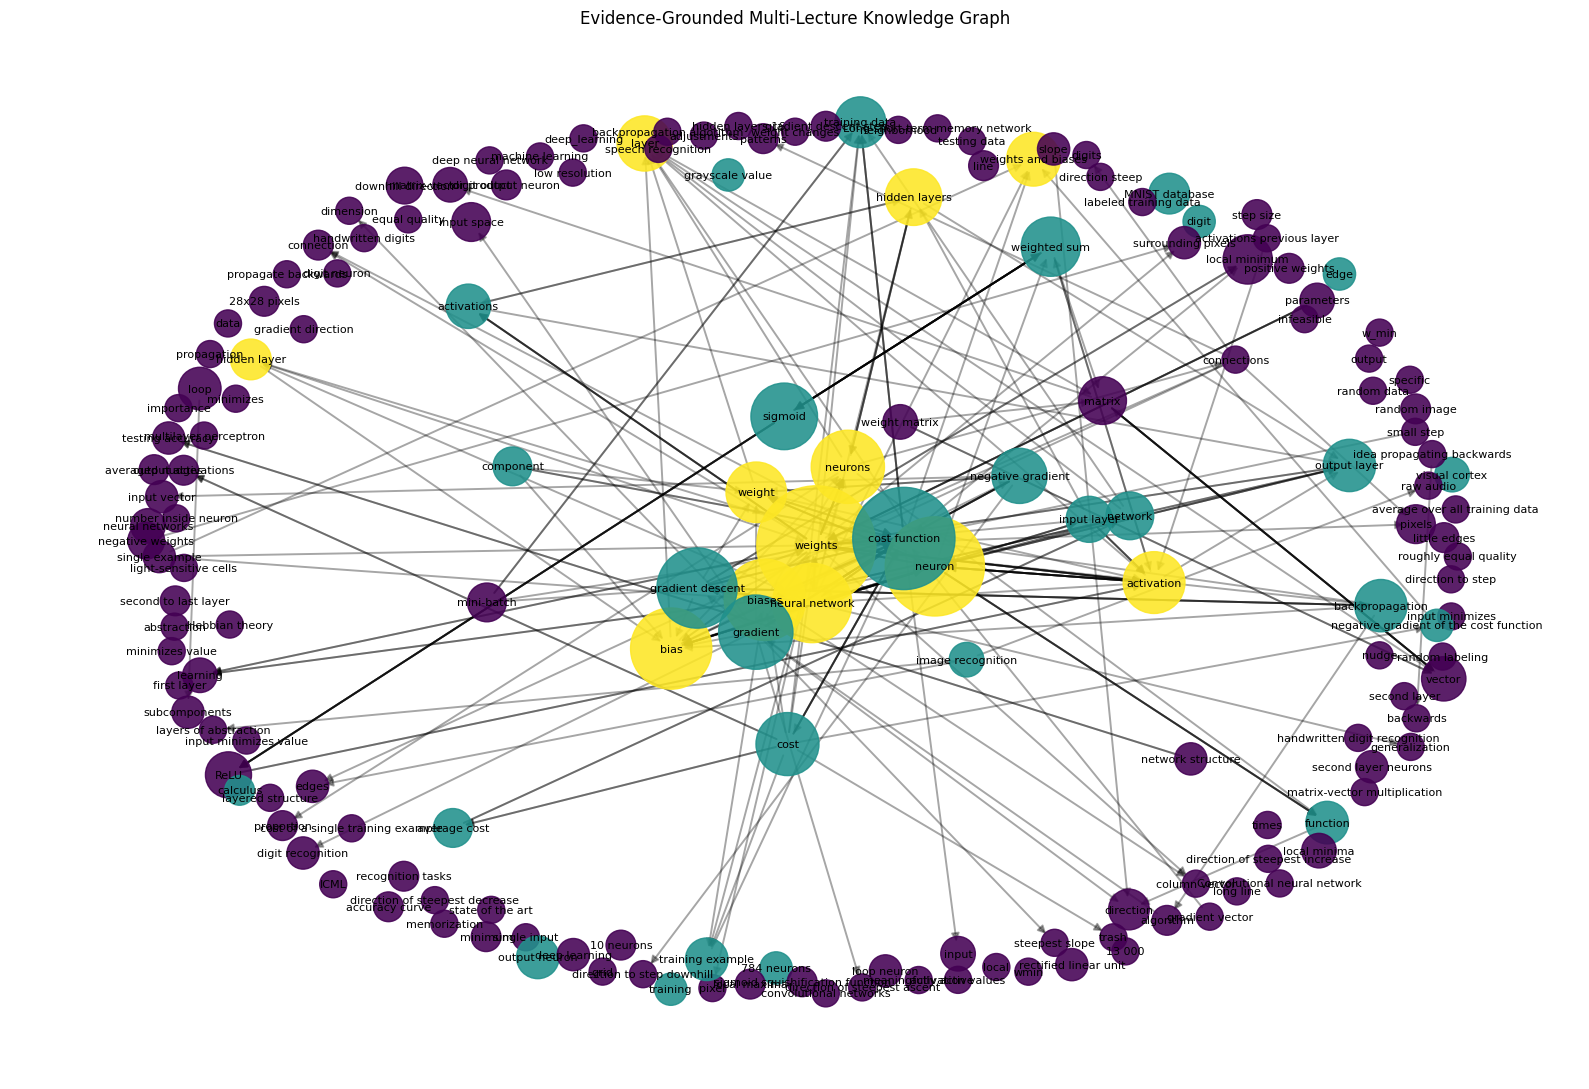

,canonical_id,display_name,primary_definition,lectures,num_lectures,evidence_count,avg_confidence,aliases
49,weights,weights,We'll do is assign a weight to each one of the...,"neural_net_01, neural_net_02, neural_net_03",3,88,0.852273,weights
86,loss function,cost function,what we mean when we talk about a network lear...,"neural_net_02, neural_net_03",2,64,0.848437,loss function
12,neuron,neuron,A component in a neural network that holds a n...,"neural_net_01, neural_net_02, neural_net_03",3,60,0.851667,neuron
58,bias,bias,An additional number added to the weighted sum...,"neural_net_01, neural_net_02, neural_net_03",3,39,0.861538,bias
61,biases,biases,The number of biases is given as 16 plus 16 pl...,"neural_net_01, neural_net_02, neural_net_03",3,39,0.853846,biases
73,gradient descent,gradient descent,An optimization algorithm used to minimize som...,"neural_net_02, neural_net_03",2,38,0.839474,gradient descent
3,neural network,neural network,A computational model inspired by the structur...,"neural_net_01, neural_net_02, neural_net_03",3,37,0.854054,neural network
108,gradient,gradient,A vector that indicates the direction of steep...,"neural_net_02, neural_net_03",2,32,0.825000,gradient
13,neurons,neurons,A collection of neurons corresponding to each ...,"neural_net_01, neural_net_02, neural_net_03",3,31,0.838710,neurons
57,sigmoid,sigmoid,A mathematical function used as an activation ...,"neural_net_01, neural_net_02",2,25,0.836000,sigmoid


In [10]:
# 9. Build evidence-grounded KG, summaries, and visualization
kept, dropped = [], []
for r in relation_mentions:
    src = alias_to_canon.get(r['source'], r['source'] if r['source'] in canonical_concepts else None)
    tgt = alias_to_canon.get(r['target'], r['target'] if r['target'] in canonical_concepts else None)
    if not src or not tgt or src == tgt or src not in canonical_concepts or tgt not in canonical_concepts:
        dropped.append({**r, 'drop_reason': 'unmapped_endpoint', 'mapped_source': src, 'mapped_target': tgt})
        continue
    kept.append({**r, 'source': src, 'target': tgt})
canonical_relationships = kept
save_json(DIRS['knowledge'] / 'canonical_relationships.json', canonical_relationships)
save_json(DIRS['knowledge'] / 'dropped_relationships.json', dropped)

G = nx.MultiDiGraph()
for cid, c in canonical_concepts.items():
    G.add_node(cid, name=c['display_name'], canonical_name=cid, primary_definition=c['primary_definition'], lectures='|'.join(c['lectures']), evidence_count=c['evidence_count'], avg_confidence=c['avg_confidence'], aliases='|'.join(c['aliases']))
for i, r in enumerate(canonical_relationships):
    G.add_edge(r['source'], r['target'], key=f"{r['type']}_{i}", type=r['type'], video_id=r['video_id'], anchor_id=r['anchor_id'], timestamp=r['timestamp'], evidence_quote=r['evidence_quote'], confidence=r['confidence'])

nx.write_graphml(G, DIRS['knowledge'] / 'knowledge_graph.graphml')
with open(DIRS['knowledge'] / 'knowledge_graph.pkl', 'wb') as f:
    pickle.dump({'graph': G, 'concepts': canonical_concepts, 'relationships': canonical_relationships, 'config': asdict(CFG)}, f)

concept_df = pd.DataFrame([{'canonical_id': cid, 'display_name': c['display_name'], 'primary_definition': c['primary_definition'], 'lectures': ', '.join(c['lectures']), 'num_lectures': len(c['lectures']), 'evidence_count': c['evidence_count'], 'avg_confidence': c['avg_confidence'], 'aliases': ', '.join(c['aliases'])} for cid, c in canonical_concepts.items()]).sort_values(['evidence_count','display_name'], ascending=[False, True])
concept_df.to_csv(DIRS['knowledge'] / 'concepts_summary.csv', index=False)
rel_df = pd.DataFrame([{'source': canonical_concepts[r['source']]['display_name'], 'target': canonical_concepts[r['target']]['display_name'], 'type': r['type'], 'video_id': r['video_id'], 'timestamp': r['timestamp'], 'confidence': r['confidence'], 'evidence_quote': r['evidence_quote']} for r in canonical_relationships])
rel_df.to_csv(DIRS['knowledge'] / 'relationships_summary.csv', index=False)
sanity = {'num_concepts': int(G.number_of_nodes()), 'num_relationships': int(G.number_of_edges()), 'relationship_endpoint_coverage': 0 if not relation_mentions else len(canonical_relationships) / len(relation_mentions), 'all_lecture_concepts': [c['display_name'] for c in canonical_concepts.values() if len(c['lectures']) == len(LECTURES)], 'avg_evidence_per_concept': float(np.mean([c['evidence_count'] for c in canonical_concepts.values()])) if canonical_concepts else 0, 'isolated_nodes': [G.nodes[n]['name'] for n in nx.isolates(G)]}
save_json(DIRS['knowledge'] / 'kg_sanity_report.json', sanity)
print(json.dumps(sanity, indent=2)[:2500])

plt.figure(figsize=(16, 11))
pos = nx.spring_layout(G, k=1.5, iterations=80, seed=7) if G.number_of_nodes() else {}
node_sizes = [300 + 80 * G.nodes[n].get('evidence_count', 1) for n in G.nodes]
node_colors = [len(str(G.nodes[n].get('lectures','')).split('|')) for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap='viridis', alpha=0.88)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=12, alpha=0.35, width=1.4)
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['name'] for n in G.nodes}, font_size=8)
plt.title('Evidence-Grounded Multi-Lecture Knowledge Graph')
plt.axis('off')
plt.tight_layout()
plt.savefig(DIRS['knowledge'] / 'knowledge_graph.png', dpi=220, bbox_inches='tight')
plt.show()
concept_df.head(25)


In [11]:
# 10. Hybrid GraphRAG retrieval, grounded QA, and evaluation scaffold
concept_ids, concept_texts = [], []
for cid, c in canonical_concepts.items():
    evidence = ' '.join(m['evidence_quote'] for m in c['mentions'][:8])
    concept_ids.append(cid)
    concept_texts.append(f"{c['display_name']} {c['primary_definition']} aliases: {' '.join(c['aliases'])} evidence: {evidence}")
concept_embeddings = embedder.encode(concept_texts, normalize_embeddings=True) if concept_texts else np.zeros((0, 1))

def retrieve_concepts(query, top_k=CFG.retrieval_top_k):
    if not concept_ids:
        return []
    q = embedder.encode([query], normalize_embeddings=True)[0]
    sem = cosine_similarity([q], concept_embeddings)[0]
    qn = normalize_name(query)
    rows = []
    for i, cid in enumerate(concept_ids):
        c = canonical_concepts[cid]
        exact = 1.0 if cid in qn or any(a in qn for a in c['aliases']) else 0.0
        fuzzy = max([fuzz.partial_ratio(a, qn) for a in c['aliases'] + [c['display_name'].lower()]] or [0]) / 100.0
        prior = min(1.0, math.log1p(c['evidence_count']) / 5.0)
        score = 0.55 * float(sem[i]) + 0.25 * exact + 0.15 * fuzzy + 0.05 * prior
        rows.append({'concept_id': cid, 'name': c['display_name'], 'score': float(score), 'semantic': float(sem[i]), 'exact': exact, 'fuzzy': fuzzy})
    rows = sorted(rows, key=lambda x: x['score'], reverse=True)
    return [r for r in rows[:top_k] if r['score'] >= CFG.retrieval_min_score]

def extract_subgraph(retrieved, hops=1):
    nodes = set(r['concept_id'] for r in retrieved)
    for _ in range(hops):
        expanded = set(nodes)
        for n in nodes:
            if n in G:
                expanded.update(G.predecessors(n))
                expanded.update(G.successors(n))
        nodes = expanded
    sub = G.subgraph(nodes).copy()
    node_items = []
    for n in sub.nodes:
        c = canonical_concepts[n]
        node_items.append({'id': n, 'name': c['display_name'], 'definition': c['primary_definition'], 'lectures': c['lectures'], 'evidence': c['mentions'][:5]})
    edge_items = []
    for u, v, k, d in sub.edges(keys=True, data=True):
        edge_items.append({'source': canonical_concepts[u]['display_name'], 'target': canonical_concepts[v]['display_name'], 'type': d.get('type'), 'video_id': d.get('video_id'), 'timestamp': d.get('timestamp'), 'evidence_quote': d.get('evidence_quote'), 'confidence': d.get('confidence')})
    return {'nodes': node_items, 'edges': edge_items}

def format_context(subgraph):
    lines = ['Concepts:']
    for n in subgraph['nodes'][:8]:
        lines.append(f"- {n['name']}: {n['definition']} | lectures={n['lectures']}")
        for ev in n['evidence'][:2]:
            lines.append(f"  evidence [{ev['video_id']} @ {ev['timestamp']:.1f}s]: {ev['evidence_quote']}")
    if subgraph['edges']:
        lines.append('\nRelationships:')
        for e in subgraph['edges'][:10]:
            lines.append(f"- {e['source']} --{e['type']}--> {e['target']} | [{e['video_id']} @ {e['timestamp']:.1f}s] {e['evidence_quote']}")
    return '\n'.join(lines)

def generate_grounded_answer(question):
    retrieved = retrieve_concepts(question)
    if not retrieved:
        return {'question': question, 'answer': 'The lectures do not provide enough evidence to answer this question.', 'retrieved': [], 'subgraph': {'nodes': [], 'edges': []}}
    subgraph = extract_subgraph(retrieved)
    context = format_context(subgraph)
    messages = [
        {'role': 'system', 'content': 'Answer only from the supplied evidence-grounded knowledge graph context. Cite lecture ids and timestamps. If unsupported, say so.'},
        {'role': 'user', 'content': f'Question: {question}\n\nKnowledge graph context:\n{context}\n\nAnswer in 3-5 sentences.'}
    ]
    text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = vlm_processor(text=[text], padding=True, return_tensors='pt').to(vlm_model.device)
    with torch.no_grad():
        out = vlm_model.generate(**inputs, max_new_tokens=350, do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out)]
    answer = vlm_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()
    return {'question': question, 'answer': answer, 'retrieved': retrieved, 'subgraph': subgraph, 'context': context}

questions = ['What is a neural network?', 'Explain the relationship between gradient descent and loss function.', 'What are prerequisites for understanding backpropagation?', 'How does activation function appear across the lectures?']
qa_results = []
for q in questions:
    res = generate_grounded_answer(q)
    qa_results.append(res)
    print('\nQUESTION:', q)
    print('RETRIEVED:', [(x['name'], round(x['score'], 3)) for x in res['retrieved']])
    print('ANSWER:', res['answer'])
save_json(DIRS['knowledge'] / 'qa_results_grounded.json', qa_results)

gold_path = DIRS['evaluation'] / 'gold_annotations.json'
if not gold_path.exists():
    save_json(gold_path, {'concepts': [], 'relationships': [], 'retrieval_questions': [
        {'question': 'What is a neural network?', 'gold_concepts': ['neural network']},
        {'question': 'What is gradient descent?', 'gold_concepts': ['gradient descent']},
        {'question': 'Explain the relationship between gradient descent and loss function.', 'gold_concepts': ['gradient descent', 'loss function']}
    ]})

def evaluate_retrieval(gold):
    rows = []
    for item in gold.get('retrieval_questions', []):
        gold_names = {normalize_name(x) for x in item.get('gold_concepts', [])}
        got = [normalize_name(r['name']) for r in retrieve_concepts(item['question'], top_k=5)]
        rows.append({'question': item['question'], 'gold': list(gold_names), 'retrieved': got, 'top1_hit': bool(got and got[0] in gold_names), 'top3_hit': bool(set(got[:3]) & gold_names), 'top5_recall': len(set(got[:5]) & gold_names) / max(1, len(gold_names))})
    return {'rows': rows, 'top1_accuracy': None if not rows else float(np.mean([r['top1_hit'] for r in rows])), 'top3_accuracy': None if not rows else float(np.mean([r['top3_hit'] for r in rows])), 'mean_top5_recall': None if not rows else float(np.mean([r['top5_recall'] for r in rows]))}

retrieval_eval = evaluate_retrieval(load_json(gold_path))
save_json(DIRS['evaluation'] / 'retrieval_eval.json', retrieval_eval)
ablation = pd.DataFrame([{'variant': 'Full evidence-grounded multimodal KG', 'num_concepts': G.number_of_nodes(), 'num_relationships': G.number_of_edges(), 'relationship_endpoint_coverage': 0 if not relation_mentions else len(canonical_relationships) / len(relation_mentions), 'retrieval_top1_accuracy': retrieval_eval.get('top1_accuracy'), 'retrieval_top3_accuracy': retrieval_eval.get('top3_accuracy'), 'mean_top5_recall': retrieval_eval.get('mean_top5_recall')}])
ablation.to_csv(DIRS['evaluation'] / 'ablation_table.csv', index=False)
print(json.dumps(retrieval_eval, indent=2))
ablation



QUESTION: What is a neural network?
RETRIEVED: [('neural network', 0.871), ('network', 0.777), ('neural networks', 0.6), ('deep neural network', 0.548), ('Convolutional neural network', 0.519), ('neuron', 0.5)]
ANSWER: A neural network is a computational model inspired by the structure and function of biological neural networks, designed to recognize patterns and make predictions. It consists of interconnected nodes or "neurons" that process information through layers. Each neuron receives inputs, processes them using a weighted sum and an activation function, and outputs a value. The network learns by minimizing a cost function, which quantifies the error between the predicted output and the actual output. This minimization is achieved through an iterative process known as gradient descent, which adjusts the weights and biases of the neurons to improve the network's performance. The goal is to generalize well to new, unseen data, ensuring the network can make accurate predictions bey

,variant,num_concepts,num_relationships,relationship_endpoint_coverage,retrieval_top1_accuracy,retrieval_top3_accuracy,mean_top5_recall
0,Full evidence-grounded multimodal KG,172,282,0.903846,1.0,1.0,1.0


## Saved artifacts

Everything is saved under the Drive run directory:

- manifest and lecture records
- frame metadata, transcripts, anchors, OCR
- raw VLM extractions
- validated concept and relationship mentions
- canonical concepts and relationships
- knowledge_graph.pkl and knowledge_graph.graphml
- concepts_summary.csv and relationships_summary.csv
- KG sanity report, grounded QA results, retrieval evaluation, ablation scaffold

For publication, manually annotate a small gold set and report concept F1, relationship precision/F1, retrieval top-k accuracy, QA faithfulness, and ablations.
